# Is ASEAN Capturing the Shift? The Regional Picture

## The Question

Notebook 01 found that South-East Asia's aggregate FDI inflows were flat in 2025, not surging, complicating the simple "capital is fleeing China for ASEAN" story at the global level. But aggregate regional data can hide a lot: is ASEAN's *composition* of investors changing even if the total isn't? Specifically, is China's own capital flowing into ASEAN even as China's global inbound FDI declines, and what are Japan and the US doing?

## The Answer

China's own investment into ASEAN has nearly tripled since 2019; up 186%, from USD 9.2 billion to USD 26.2 billion in 2025, with the sharpest jump in the most recent two years. This is a genuinely different mechanism from the popular narrative: it isn't Western firms redirecting investment away from China into South-East Asia; it's Chinese firms themselves increasingly investing directly into ASEAN, plausibly to relocate production and route around tariffs on Chinese-origin goods. Meanwhile, Japan's investment into ASEAN has fallen 57% since 2019, and US investment is down 38% (though volatile, with an outlier 2023 spike). The region isn't seeing broad-based Western reshoring into it; it's absorbing a rising wave of Chinese capital specifically, while two of its other traditional major investors pull back.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

asean_fdi = pd.read_csv('../data/processed/asean_fdi_by_source.csv')
asean_fdi.head()

,source_country,year,fdi_inflow_usd_million
0,China,2019,9181.17
1,China,2020,7257.10
2,China,2021,17172.02
3,China,2022,16588.47
4,China,2023,16551.01


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## How much has each source country's investment into ASEAN changed since 2019?

In [3]:
summary = []
for country in ['China', 'Japan', 'United States']:
    d = asean_fdi[asean_fdi['source_country'] == country].set_index('year')['fdi_inflow_usd_million']
    total_change = (d.loc[2025] / d.loc[2019] - 1) * 100
    summary.append({'source_country': country, '2019_usd_m': d.loc[2019], '2025_usd_m': d.loc[2025],
                     'total_change_pct': round(total_change, 0)})

summary_df = pd.DataFrame(summary).set_index('source_country')
summary_df

,2019_usd_m,2025_usd_m,total_change_pct
source_country,,,
China,9181.17,26243.68,186.0
Japan,21985.15,9557.86,-57.0
United States,48323.12,30044.76,-38.0


## Visualizing the diverging trajectories

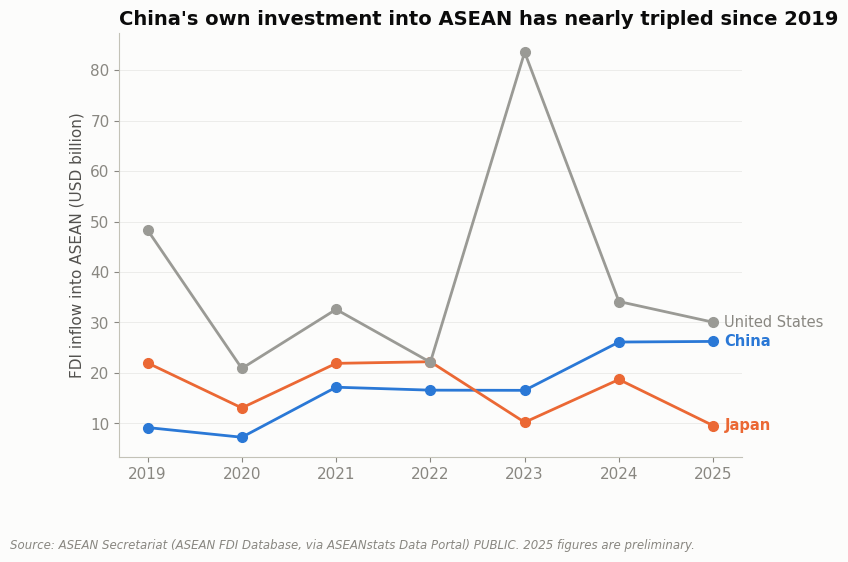

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = {'China': ACCENT_1, 'Japan': ACCENT_2, 'United States': GRAY}
weights = {'China': 'bold', 'Japan': 'bold', 'United States': 'normal'}

for country in ['China', 'Japan', 'United States']:
    d = asean_fdi[asean_fdi['source_country'] == country].set_index('year')['fdi_inflow_usd_million'] / 1000
    ax.plot(d.index, d.values, marker='o', markersize=7, linewidth=2, color=colors[country])
    label_color = colors[country] if country != 'United States' else INK_MUTED
    end_label(ax, d.index[-1], d.values[-1], country, label_color, weight=weights[country])

ax.set_title("China's own investment into ASEAN has nearly tripled since 2019", loc='left')
ax.set_ylabel('FDI inflow into ASEAN (USD billion)')
ax.set_xlabel('')
fig.subplots_adjust(right=0.78)

add_source(ax.figure, 'Source: ASEAN Secretariat (ASEAN FDI Database, via ASEANstats Data Portal) PUBLIC. '
                       '2025 figures are preliminary.')
plt.show()

## Strategic Recommendation

- **A business benchmarking "reshoring into ASEAN" should specify *whose* capital, not just whether regional totals are rising.** The region's aggregate FDI is flat, but that masks a real compositional shift: rising Chinese investment offsetting falling Japanese and volatile US investment.
- **Chinese-origin manufacturing relocation into ASEAN is the more defensible version of the "China+1" story here, not Western reshoring.** Businesses evaluating supply-chain partners in the region should weight this: a "Made in ASEAN" product increasingly may still trace back to Chinese-owned capital and management, which matters for tariff-avoidance strategies that assume genuine origin diversification.
- **Japan's declining ASEAN-wide investment is worth watching against Malaysia's own numbers specifically** (Notebook 03); if Malaysia is bucking that regional decline, it would be a genuine local capture story worth understanding.

## Confidence & Caveats

- **This is ASEAN-aggregate data, not Malaysia-specific**; it cannot say whether any individual member state, including Malaysia, is following the regional pattern or diverging from it. That is exactly what Notebook 03 tests.
- **Large single-year swings (US 2023 at USD 83.5 billion, more than double every other year in the series) likely reflect one or a handful of large deals**, not a smooth trend; this analysis has no deal-level data to confirm what drove that spike, and it pulls the "total change since 2019" summary number for the US in a direction a smoother series might not.
- **2025 figures are marked preliminary by ASEANstats** as of the most recent data update and may be revised.
- **This cannot distinguish *why* Chinese investment into ASEAN is rising**; tariff avoidance, genuine regional market access, cost, or other motives could each explain part of it, and this data cannot separate them.

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's core finding; kept separate from the PUBLIC ASEANstats figures above. Full citations in [`references/SOURCES.md`](../references/SOURCES.md).*

Independent reporting converges on one primary driver: **US tariff policy is pushing Chinese firms to build real production capacity inside ASEAN, not just route goods through it.**

- When the US-China trade war first opened in 2018, the initial Chinese response was mostly **transshipment**; goods made in China, shipped through a South-East Asian country with minimal processing, and re-labeled with that country's origin to dodge tariffs aimed at China specifically.
- That has since evolved into **direct investment**: Chinese automakers now operate full assembly lines in Thailand and Indonesia; in August 2025, BYD began exporting Thailand-built EVs to Europe. Between 2018–2024, automotive alone accounted for 45% of all Chinese investment into ASEAN, with electronics and renewable-energy technology at 15% each.
- Trump's April 2025 "reciprocal" tariffs, which hit South-East Asian exporters directly rather than only China, accelerated this further; Chinese President Xi Jinping toured the region that same month, and Chinese firms have continued shifting from "ship through" to "build here" as a hedge against tariffs on *both* China and its neighbors.

This matters for how this notebook's finding should be read: it isn't that Western firms are diversifying away from China into ASEAN (the popular "China+1" framing); it's that **Chinese firms themselves are diversifying their own production footprint**, largely in response to US trade policy rather than a broader "leaving China" sentiment.

**Sources:** [The Diplomat, "Amid Trump Tariffs, Chinese Enterprises Reposition in Southeast Asia"](https://thediplomat.com/2025/10/amid-trump-tariffs-chinese-enterprises-reposition-in-southeast-asia/), October 2025; [S&P Global, "What does transshipment trade mean for China-ASEAN trade and US tariffs"](https://www.spglobal.com/market-intelligence/en/news-insights/research/2025/10/what-does-transshipment-trade-mean-for-china-asean-trade-and-us-tariffs), October 2025.